<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section06_Natural_Language_Processing/Chapter01_Attention_Is_All_You_Need.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CONTEXT-DEPENDENCY IN NLP**

In the previous notebook, we explored the idea of **word embeddings** — one of the most powerful concepts in Natural Language Processing. By mapping words into a continuous vector space, we gave our models the ability to understand words and their relationships.  

But let’s pause for a moment and ask a deeper question:  
**Does a word always carry the same meaning, regardless of its context?**

Take the word **“mouse”** for example, and give some words related to it  
- One person might immediately think of: *cheese, long tail, rodent, cat...*  
- Another person might instead list: *computer, wireless, keyboard, click...*  

Both are correct — they’re simply thinking about **different contexts**.  

This is where embeddings start to struggle. A `word2vec` or `glove` model will always assign a **single fixed vector** to *“mouse.”* As a result, this embedding shows high similarity not only to animal-related words (*cat, cheese*) but also to device-related words (*computer, wireless*).  
The problem? Words like **“cheese”** and **“keyboard”** are completely unrelated, yet embeddings pull them together simply because they both connect to *“mouse.”*  

That’s a limitation of fixed embeddings:  
- Words with multiple meanings get **collapsed** into a single vector.  
- Context is ignored.  

What we really need is a way to give words a **context-dependent representation.**  
If *“mouse”* appears in *“a hungry mouse searching for cheese”*, its vector should shift closer to animals.  
If it appears in *“a wireless mouse clicking on a file”*, its vector should instead align with electrical devices.  

This is the fundamental problem we are targeting in this chapter. To explore how NLP has tried to solve it, we will walk through two major steps in its history: first, how **recurrent neural networks (RNNs)** approached the problem, and then how the **Transformers** — using the **Attention Mechanism** — completely changed the game.

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import gensim.downloader as api
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Load Word2Vec model
print("Loading Word2Vec model...")
word2vec = api.load('glove-twitter-25')
print(f'Loaded {len(word2vec.key_to_index)} word embeddings with {word2vec.vector_size} dimensions')

Loading Word2Vec model...
[==================================================] 100.0% 104.8/104.8MB downloaded
Loaded 1193514 word embeddings with 25 dimensions


In [ ]:
# UTILITY FUNCTIONS
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

def get_embedding(token):
    """Get word embedding with fallback handling"""
    token = token.lower().strip('.,!?;()[]')
    if token in word2vec.key_to_index:
        return word2vec[token]
    # Deterministic fallback for unknown words
    rnd = np.random.RandomState(abs(hash(token)) % (2**32))
    return rnd.normal(scale=0.1, size=(word2vec.vector_size,)).astype(np.float32)

def tokenize(sentence):
    """Simple tokenization"""
    return sentence.lower().split()

def embed_sentence(sentence):
    """Convert sentence to tensor of embeddings"""
    tokens = tokenize(sentence)
    embeddings = [get_embedding(token) for token in tokens]
    return torch.tensor(embeddings, dtype=torch.float32)

def pad_collate(batch):
    """Collate function for batching with padding"""
    sequences = [item[0] for item in batch]
    mouse_positions = [item[1] for item in batch]
    labels = [item[2] for item in batch]

    # Get dimensions
    lengths = [seq.size(0) for seq in sequences]
    max_len = max(lengths)
    embed_dim = sequences[0].size(1)

    # Create padded batch
    padded_seqs = torch.zeros(len(batch), max_len, embed_dim)
    attention_masks = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, seq in enumerate(sequences):
        length = seq.size(0)
        padded_seqs[i, :length] = seq
        attention_masks[i, :length] = True

    return (padded_seqs, attention_masks,
            torch.tensor(mouse_positions), torch.tensor(labels))

In [ ]:
# Demonstrate static embeddings: Compute cosine similarities for 'mouse'
mouse_vec = get_embedding('mouse')
related_words = ['cat', 'hamster', 'keyboard', 'spider', 'camera', 'tail', 'laser', 'screen', 'microphone', 'wheel', 'mickey', 'pet', 'flash', 'rabbit', ]

print("Cosine Similarity between 'mouse' and related words:")
for word in related_words:
    word_vec = get_embedding(word)
    similarity = cosine_similarity([mouse_vec], [word_vec])[0][0]
    print(f" mouse ~ {word:-<11}> {similarity:.4f}")

print(f'{"-"*30}\n tail  ~ {"wheel":-<11}> {cosine_similarity([word2vec["tail"]], [word2vec["wheel"]])[0][0]:.4f}')
print(f' pet   ~ {"flash":-<11}> {cosine_similarity([word2vec["pet"]], [word2vec["flash"]])[0][0]:.4f}')
print(f' wheel ~ {"rabbit":-<11}> {cosine_similarity([word2vec["wheel"]], [word2vec["rabbit"]])[0][0]:.4f}')
print(f' cat   ~ {"flash":-<11}> {cosine_similarity([word2vec["cat"]], [word2vec["flash"]])[0][0]:.4f}')

Cosine Similarity between 'mouse' and related words:
 mouse ~ cat--------> 0.8381
 mouse ~ hamster----> 0.8361
 mouse ~ keyboard---> 0.8335
 mouse ~ spider-----> 0.8271
 mouse ~ camera-----> 0.8225
 mouse ~ tail-------> 0.8144
 mouse ~ laser------> 0.8050
 mouse ~ screen-----> 0.8049
 mouse ~ microphone-> 0.8043
 mouse ~ wheel------> 0.8015
 mouse ~ mickey-----> 0.7997
 mouse ~ pet--------> 0.7979
 mouse ~ flash------> 0.7964
 mouse ~ rabbit-----> 0.7962
------------------------------
 tail  ~ wheel------> 0.8346
 pet   ~ flash------> 0.7372
 wheel ~ rabbit-----> 0.7272
 cat   ~ flash------> 0.7231


## **Recurrent Neural Networks**

As you can see from the outputs above, which have come from a word embedding dataset named **glove-twitter-25**, the word *mouse* shows high similarity to words that might individually make sense with it, but don’t actually belong together. They come from **two different contexts**.

One of the earliest and most widely used methods of solving this issue of fixed word embeddings was the idea of using a **Recurrent Neural Network (RNN)**.

Recurrent neural networks were inspired by the way the human brain understands the context in which a word appears. It’s actually very simple: when you read a piece of text and encounter the word *mouse*, you rarely get confused about whether it means an animal or a computer device.

Why? Because you have a **memory** of all the words you’ve read so far.

Take the text below as an example:

> “... one day, a fluffy cat was wandering through the barn, hungry and tired. It sniffed around piles of hay, looking for food. Suddenly, it caught the scent of something familiar — a piece of cheese sitting dangerously close to a trap. The cat ignored the cheese, because it wasn’t after dairy. Instead, it crouched silently, waiting for the tiny **mouse**...”

As soon as you read the word *mouse* here, you would **never think of a computer mouse**. The previous words you read so far like *cat, barn, cheese, trap* already made it very clear that we’re talking about the *animal*.

RNNs apply this exact principle to sequences of words.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S06_C01/rnn.png" width="600">
  <h5>Figure 0: Recurrent Neural Network's Architecture</h5>
</div>

### **How RNNs Work**

An RNN is made of a chain of neurons, where each neuron:

* Takes the current input word (token),
* Combines it with a “memory” from the past,
* Produces an output,
* And passes on the updated memory to the next neuron in the chain.

This way, by the time you reach the *i-th* word in a sentence, the network has already “remembered” everything that came before it.

Mathematically, this can be written as follows:

$$
h_t = f(W_x \cdot x_t + W_h \cdot h_{t-1})
$$

* $x_t$ = the input word embedding at time step *t*
* $h_{t-1}$ = the hidden state (memory) from the previous step
* $W_x, W_h$ = weight matrices (learnable parameters)
* $f(\cdot)$ = activation function
* $h_t$ = the new hidden state (updated memory)

If the task requires an output at each step (like in translation or sequence labeling), then:

$$
y_t = \text{softmax}(W_y \cdot h_t)
$$

This means the hidden state is also used to predict something about the current word, while still carrying forward the memory.

RNNs became extremely popular because they were the first neural networks that could **handle sequential data** — data where the meaning depends on order. Examples include:

* Text (words, sentences and paragraphs)
* Audio (speech, music)
* Video (frames over time)

Because of their usefulness, many **variations** of RNNs were created, each designed to address specific problems like long-term dependencies or training efficiency. The fundamental principle remains the same, but the mechanics differ.

Two of the most famous variations are:

* **LSTM (Long Short-Term Memory):** introduces gates (input, forget, output) to control how much of the past memory to keep or forget, making it possible to remember dependencies over much longer sequences.
* **GRU (Gated Recurrent Unit):** a simpler version of LSTM with fewer gates, making it computationally lighter but still effective in capturing longer-term dependencies.

We won’t dive into the details of LSTM and GRU here, as each could fill an entire chapter by themselves. For now, it’s enough to know that they were designed to improve on the limitations of vanilla RNNs.

### **Weakpoints of RNNs**

RNNs and their variations, as we mentioned, were widely used in NLP for different tasks for decades. We could feed a **sequence of words** into an RNN and let it produce outputs at each step based on its hidden states. Or, we could define a `k` value — meaning the network should wait until the *k-th* hidden state before starting to produce outputs.  
This was especially useful in tasks like **translation**, where it helps to “listen” to a sentence until midway before trying to translate it.  

Similarly, we could feed in an entire sentence, let the RNN reach the **final token**, and then take its last hidden state $h_t$ as a **summary of the whole sequence**. That single vector could then be passed into a classifier for tasks like:  
- **Sentiment analysis** (positive or negative tone)  
- **Detecting psychological distress** in a person’s speech  
- **Categorizing news** into domains like sports, politics, entertainment, etc.  

RNNs were powerful — but their architecture also suffered from **serious challenges**.

#### **1. Gradient Vanishing / Exploding**  
As we studied in earlier chapters, deep networks often face **vanishing gradients** due to repeated activation squashing.  
The same problem applies here.  

- A normal English sentence has **~15–20 words on average**, and in some languages (like German or Turkish), it can be much longer.  
- Every time a hidden state passes through an activation like `tanh`, values are squeezed into $[-1,1]$.  
- As this process repeats across time steps, the gradients shrink more and more.  
- By the time we reach the last word in the sentence, the network may have **lost all memory of the first few words**.  

The opposite can also happen (**exploding gradients**), though vanishing is more common.

#### **2. Long-Term Dependencies**  
This vanishing gradient issue leads directly to another major problem: **losing long-range information**.  

Take the example sentence:  

> “My computer, which I had serious issues with — and all of my friends had noticed and kept reminding me to fix — finally seems to work fine now. I think I just need to replace my **mouse**.”  

An RNN would have a good memory of the word **computer** when it’s only a few words behind. But as the sentence grows longer, that memory fades. By the time the network reaches the final word *mouse*, it has almost **no clue** whether the sentence refers to a **computer mouse** or the **animal**.  

#### **3. Lack of Parallelization**  
Another major inefficiency: **RNNs are inherently sequential**. Each neuron must **wait for the previous one** before it can compute its own hidden state.  
This is like a kitchen with multiple chefs:  
- The first chef must peel the potatoes.  
- Only then can the second chef cut them.  
- And only after that can the third chef fry them.  

Until the first step is complete, the others are forced to wait — wasting resources. For RNNs, this means training on large datasets becomes extremely **slow and resource-hungry**. If it takes 1 second to process a word, a dataset of 1 million words will take **over 11 days** to process on a single thread — clearly not practical.

All these challenges were addressed in 2017 by Google in their groundbreaking paper: [Attention Is All You Need](https://arxiv.org/abs/1706.03762).  

This paper introduced a new architecture called the **Transformer**, which solved all the RNN problems together by introducing a mechanism known as **Attention**.  

The Transformer architecture:  
- Uses **residual connections**, preventing vanishing gradients.  
- Is **independent of sentence length** — any word can connect directly to any other.  
- Most importantly, it is **fully parallelizable**: all words in a sentence can be processed **at the same time**.  

Let’s now dive into the **building blocks of this “magic” architecture** and see how Attention actually works.

## **The Attention Mechanism**

Let's start excavating this mechanism with a pretty simple idea from Database Management Systems (DBMS). In DBMS we have things called **Queries**, **Keys**, and **Values**. What they literally mean is something like this:

* A **Query** is the thing that I’m currently looking for, let’s say: *“a good place to eat pizza in”*.
* Suppose that we have a big database of all the restaurants in my city, and each one of them has a unique name. These **names** are called the **Keys**, the things that identify each entity in the database.
* Once we match my query with the database keys, we get back the restaurant’s actual details: address, menu, average price, reviews, etc. These are the **Values**.

So the DBMS process looks like this: The query is matched against keys → the matching keys lead us to the corresponding values → the values are returned as results.

---

Now let’s switch to NLP and think of it this way:

What if we suppose all the **words in a sentence** as individual queries, and again let the **same words also serve as the keys**? We already have embedding vectors for each of those words. So if we take the embeddings and multiply the queries with the keys (a dot product between the embedding vectors of all the words in the sentence with themselves), we get a score that measures **how aligned or similar** each of the words are.

Since we do this for *every pair of words in the sentence*, we end up with a matrix of scores of size **\$n \times n\$**, where \$n\$ is the number of tokens in our sentence. Mathematically, this is just \$Q \cdot K^T\$ (a dot product between each of the Queries and the Keys).

* Each **row** of this matrix corresponds to one query word.
* The entries in that row are the similarity scores between that query and all the keys (i.e., all other words in the sentence).

To make these scores more interpretable, we apply a **softmax row-wise** (not column-wise). Why? Because for each query, we want the similarities to form a probability distribution across all words in the sentence. After softmax, each row sums to 1, and every number is squeezed into the range $[0, 1]$.

This gives us what we can call an **Attention Pattern Matrix**.

---

### **Why do we call it "attention"?**

Because it literally tells us **how much one word should attend to another word** when interpreting its meaning.

For example:

* The similarity between “mouse” and “galaxy” will be very low, so in the attention pattern, the query “mouse” won’t assign much weight to the word “galaxy.”
* On the other hand, the similarity between “mouse” and “monitor” might be high. That means the query “mouse” is attending a lot to the word “monitor.”

This mirrors what we humans do. When we read a passage and encounter the word “mouse,” we don’t stare at irrelevant words like “galaxy” to figure out its meaning — instead, we focus our **attention** on words like “monitor,” “keyboard,” or “cheese,” depending on the context, that we know have some closeness to the word mouse.

Now that we have this Attention Pattern Matrix, the real magic begins.

If we just stopped here, we would only know *which words are related* and *how strongly*. But we also want to **use those relations to update our representation of each word**.

To do this, we multiply the Attention Pattern Matrix with the **Values** (which are once again our word embeddings).

Mathematically:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left({QK^T}\right) \cdot V
$$

So what does this mean intuitively?

For each query word, we now take a **weighted sum** of all the value vectors. The weights come from the attention pattern: high similarity → high weight, low similarity → low weight.

In plain terms:

* The word “mouse” builds a new vector for itself by mixing information from “monitor” and “keyboard” (because it attended to them strongly), while largely ignoring irrelevant words like “galaxy”, “sandwich”, “she”, “the...”
* Each word does this in parallel for itself.

The result is a **new set of word representations** that carry contextual meaning. Instead of every word standing alone, each one is now enriched by the words it pays attention to. In this new embedding vector of the word “mouse” we would now expect it to converge towards a specific concept (either an animal, or a device) based on the words in its context.

### **Scaling Factor**

When we look at the original paper, there is indeed a difference we see in the formula: a scaling factor of $\sqrt{d_k}$ by which each attention score is divided *before* applying softmax.  

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) \cdot V
$$

Why? Without scaling, the dot products $QK^T$ can grow very large as the dimensionality $d_k$ increases. For example, in a 512-dimensional embedding space, even random vectors can have dot products in the tens or hundreds.  

Imagine we get scores like **25, -2, and 0.05**. When passed through softmax, these turn into $e^{25}$, $e^{-2}$, and $e^{0.05}$. Since $e^{25}$ is astronomically larger than the others, the resulting distribution will assign nearly all the weight to the score 25, and the others will be crushed close to zero.  

This behavior is harmful because attention should usually be *shared* across several useful words, not collapse into a one-hot choice. By dividing by $\sqrt{d_k}$, we reduce the variance of the dot products, keeping them in a range where softmax can produce smoother, more balanced probability distributions.  

### **Learning Transformations**

Earlier we said Queries, Keys, and Values were "just the embeddings" to keep it simple for beginners. Now let’s correct that: they are not the raw embeddings themselves, but **linear transformations** of them.  

We introduce three trainable matrices $W_q$, $W_k$, and $W_v$, and compute:  

$$
Q = XW_q, \quad K = XW_k, \quad V = XW_v
$$  

where $X$ is the matrix of word embeddings coming from a `word2vec` for example.  

So why bother with these extra transformations instead of using embeddings directly? Here are the main reasons:

- **Adaptation and learning flexibility**  
  If Queries, Keys, and Values were fixed, the model would always attend based on the original word embeddings. For example:  
  *Sentence:* *“A mouse ran across my keyboard.”*  
  With static embeddings, "mouse" might always attend to "keyboard," because the embedding space strongly links them. But in this sentence, the intended meaning is the animal. By using trainable $W_q$, $W_k$, and $W_v$, the model can learn (through backpropagation) to shift attention away from "keyboard" and toward "ran across," gradually correcting its mistake.

- **Different perspectives on relationships**  
  Words don’t only relate by similarity. They connect by **semantics**, **grammar**, **logic ...**.  
  For example:  
  - Semantic: *mouse → cheese*  
  - Functional (noun + verb): *mouse → eats*  
  - Grammatical (noun + adj): *mouse → its*  
  If we used raw embeddings, all these relationships would be compressed into a single vector space. By introducing learnable weights, we allow multiple “views” of the same word. This becomes essential in **multi-head attention**, where each head has its own $W_q, W_k, W_v$ and thus can capture a different type of relation.

- **Trainability is essential**  
  Without these weights, attention would be a static lookup based on embeddings, like k-NN search in vector space. But attention is meant to be *trainable*: the model should discover which kinds of relationships matter for the task at hand. The learnable matrices make the mechanism end-to-end trainable with the rest of the neural network.

### **Masking the Scores**

Sometimes, before applying softmax to the $QK^T$ scores, we deliberately **mask** certain positions in the attention matrix. Masking simply means setting those scores to $-\infty$ (or a very large negative number) so that after softmax, they become exactly zero and are ignored.

But why would we want to do this?

- **Causal Masking (for autoregressive tasks):**  
  When generating text word by word, the model must not "peek" into the future. For example, if we’re predicting the 5th word in a sentence, it should only attend to the first 4 words, not the 6th or 7th. By masking out all positions beyond the current one, we ensure the model behaves like a left-to-right reader.  
  *This is what makes GPT-style models possible.*

- **Padding Masking (for variable-length sentences):**  
  In a batch of sentences, some are shorter than others. We pad them with special tokens (like `<PAD>`). But we don’t want the model to waste attention on these artificial tokens. By masking them, we force the attention to ignore padding and only focus on real words.  

Masking is **not always necessary**, but it unlocks critical behaviors:  
- Enables **causal text generation** (no cheating from future words).  
- Handles **variable-length input** cleanly.  
- Ensures the model’s focus stays only on meaningful tokens.  

Basically, masking acts like **blinders** on a horse: it narrows the model’s field of view so it can only attend to the words that are valid and relevant in that specific scenario.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S06_C01/self_attention.png" width="150">
  <h5>Figure 1: Scaled dot-product attention structure</h5>
</div>

**Image Credit:** [Original Paper](https://arxiv.org/abs/1706.03762)

In [ ]:
class ScaledDotProductAttention(nn.Module):
    """
    Attention(Q, K, V) = softmax(QK^T / √d_k)V
    """
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q: Query tensor (batch, heads, seq_len, head_dim)
            K: Key tensor   (batch, heads, seq_len, head_dim)
            V: Value tensor (batch, heads, seq_len, head_dim)
            mask: Already processed mask with -1e9 values (batch, heads, seq_len, seq_len)
        """
        # Get dimensions
        d_k = Q.size(-1)  # head_dim

        # Step 1: Compute QK^T / √d_k (scaled dot-product)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)

        # Step 2: Apply pre-processed mask if provided
        if mask is not None:
            scores = scores + mask  # mask already contains -∞ for invalid positions

        # Step 3: Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        # Step 4: Apply attention weights to values
        context = torch.matmul(attention_weights, V)

        return context, attention_weights

### **Multi-Head Attention**

What we covered so far is called a **self-attention mechanism** — because Queries, Keys, and Values all come from the same sequence (for example, the words in one sentence). This is extremely useful whenever we want a model to understand *relationships within a sequence itself*, such as dependencies between words in a sentence.

There is also another variant called **cross-attention**, where the Queries come from one sequence while the Keys and Values come from a different sequence. This is especially important in tasks like **translation**. In French to English translation for example, the query words are from a French sentence and attend their English equivalent words. In fact, the Transformer architecture we will study soon uses **self-attention in its encoder** and **cross-attention in its decoder**.

But the *really exciting leap* comes when we realize we don’t have to stop at just one attention head.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S06_C01/multi_head.png" width="250">
  <h5>Figure 2: Multi-head attention structure</h5>
</div>

**Image Credit:** [Original Paper](https://arxiv.org/abs/1706.03762)

Remember how we studied the perceptron and then stacked many of them to form a neural network? The same idea applies here: instead of a single self-attention head, we can have **multiple heads** running in parallel. Each head can learn to focus on a *different aspect of the relationships* between words. Afterward, their outputs are concatenated, giving the model a richer, multi-dimensional understanding of the sequence.

Take this sentence as an example:

**"The scientist who discovered the vaccine won a prestigious award."**

If we only had one attention head, maybe the word *scientist* mostly attends to *discovered*. That’s useful, but not the whole story. With multiple heads, we can capture much more:

* One head may connect *scientist* ↔ *vaccine* (role and object).
* Another head may link *scientist* ↔ *award* (subject and achievement).
* Another may focus on *who* ↔ *scientist* (grammatical structure).
* Yet another may highlight *discovered* ↔ *vaccine* (verb-object relation).

Each head gives us a **different “view” of the same sentence**. When combined, the model gains a holistic and powerful representation — much like stacking perceptrons gave us the expressive power of neural networks. Multi-head attention captures *many relationship patterns simultaneously*, enabling deeper and more nuanced understanding.

In [ ]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Attention using multiple Scaled Dot-Product Attention heads"""
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # The core attention mechanism
        self.scaled_dot_product_attention = ScaledDotProductAttention(dropout)

        # Linear projections
        self.q_linear = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_linear = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_linear = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_linear = nn.Linear(embed_dim, embed_dim, bias=False)

        self._init_weights()

    def _init_weights(self):
        for module in [self.q_linear, self.k_linear, self.v_linear, self.out_linear]:
            nn.init.xavier_uniform_(module.weight)

    def forward(self, x, mask=None):
        batch_size, seq_len, embed_dim = x.size()

        # Linear projections and reshape for multi-head
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Process mask for attention scores
        processed_mask = None
        if mask is not None:
            # mask: (batch, seq_len) -> need (batch, heads, seq_len, seq_len)
            mask = mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)
            processed_mask = torch.zeros_like(torch.matmul(Q, K.transpose(-2, -1)))
            processed_mask.masked_fill_(~mask, -np.inf)

        # Apply scaled dot-product attention
        context, attention_weights = self.scaled_dot_product_attention(Q, K, V, processed_mask)

        # Concatenate heads and apply final projection
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        output = self.out_linear(context)

        return output, attention_weights

### **Positional Encoding**

One major difference between **RNNs** and **Transformers** lies in how they treat word order.  
- RNNs inherently process tokens *sequentially*, so the notion of order is built-in.  
- Transformers, however, see the *entire sequence at once*. This parallelism is powerful, but it comes with a problem: the model has **no idea which word comes first, last, or in-between**.  

Without positions, a sentence like:  
- **"The cat eats the chicken."**  
could look identical to  
- **"The chicken eats the cat."**  

Both would produce the *same embeddings* for “cat” and “chicken,” even though their roles are reversed — making the meaning totally different and misleading.  

To fix this, the original Transformer introduces **Positional Encodings** that inject information about each token’s position into its embedding.  

The encoding uses sine and cosine functions of different frequencies:

$$
PE_{(pos,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE_{(pos,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

Where:  
- $pos$ = position of the word in the sequence (0, 1, 2, …).  
- $i$ = dimension index of the embedding vector.  
- $d_{model}$ = total embedding dimension.  

This way, every position is encoded as a unique **wave pattern** across embedding dimensions.  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S06_C01/positional_encoding.png" width="700">
  <h5>Figure 3: Sinusoidal positional encoding</h5>
</div>

**Image Credit:** [Original Website](https://commons.wikimedia.org/w/index.php?search=Positional+encoding&title=Special%3AMediaSearch&type=image)

### **Why does it work?**

The authors themselves admitted: *“We chose sinusoidal functions because we hypothesize that they allow the model to easily learn to attend by relative positions.”*  
It’s not mathematically proven that this is *the* best method, but experiments showed it worked remarkably well.  
Here’s why researchers think it helps:

- **Unique fingerprints**: Every position has a distinct pattern of sine/cosine values. Two different positions will never produce identical encodings.  
- **Relative position awareness**: Because sinusoids are continuous and periodic, differences between positions are encoded in the *phase shift*. For example, the model can learn that “word A is 5 tokens ahead of word B” simply by comparing wave patterns.  
- **Multi-scale resolution**: Using different frequencies allows the encoding to capture both *fine-grained* (local word-to-word) and *coarse* (global-distance) relationships.

By **adding positional encodings to the word embeddings**, the Transformer now knows not just *what* a word is, but also *where* it is.  

For example:  
- In **"The cat eats the chicken"**, the roles of *cat* and *chicken* only make sense because of their positions.  
- Without positional information, *cat* and *chicken* could be swapped and the network would not notice the change in meaning.  

In [ ]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding"""
    def __init__(self, embed_dim, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = 1.0 / (10000 ** (torch.arange(0, embed_dim, 2).float() / embed_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        if embed_dim % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])  # Remove last element for odd dimensions
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#### **Code Insights**

In the tiny implementation below you could see how this positional encoding technique has affected words based on their positions in the sentences **"the cat eats the chicken"** and **"the chicken eats the cat"**.

In both of the sentences we have the words *cat* and *chicken* in the same context, so they would give exactly similar embedding vectors after the attention mechanism. However, the meanings of those two sentences are completely different from each other.

From the **heatmaps of the positionally encoded embedding vectors** for words in each sentence, you can see how the words *chicken* and *cat* have changed their embedding vectors based on their positions. (Notice how the updates are strongest in the earlier dimensions — compare the first 5 dimensions and you’ll spot the difference clearly.)

We then calculated the **cosine similarity** of the word `cat` with itself across the two sentences. Even though the contexts are the same, the positional encodings make the vectors no longer *100% identical*. The same holds true for the word `chicken`. It’s as if Positional Encoding has injected the logic that these two chickens are **semantically the same**, but **structurally different** — their roles in the sentence are not interchangeable.

Even the word `the` shows differences across the same sentence — its embeddings shift depending on whether it modifies `cat` or `chicken`. Positional encoding gives the model the capacity to realize that even these two `the`s are not the same.

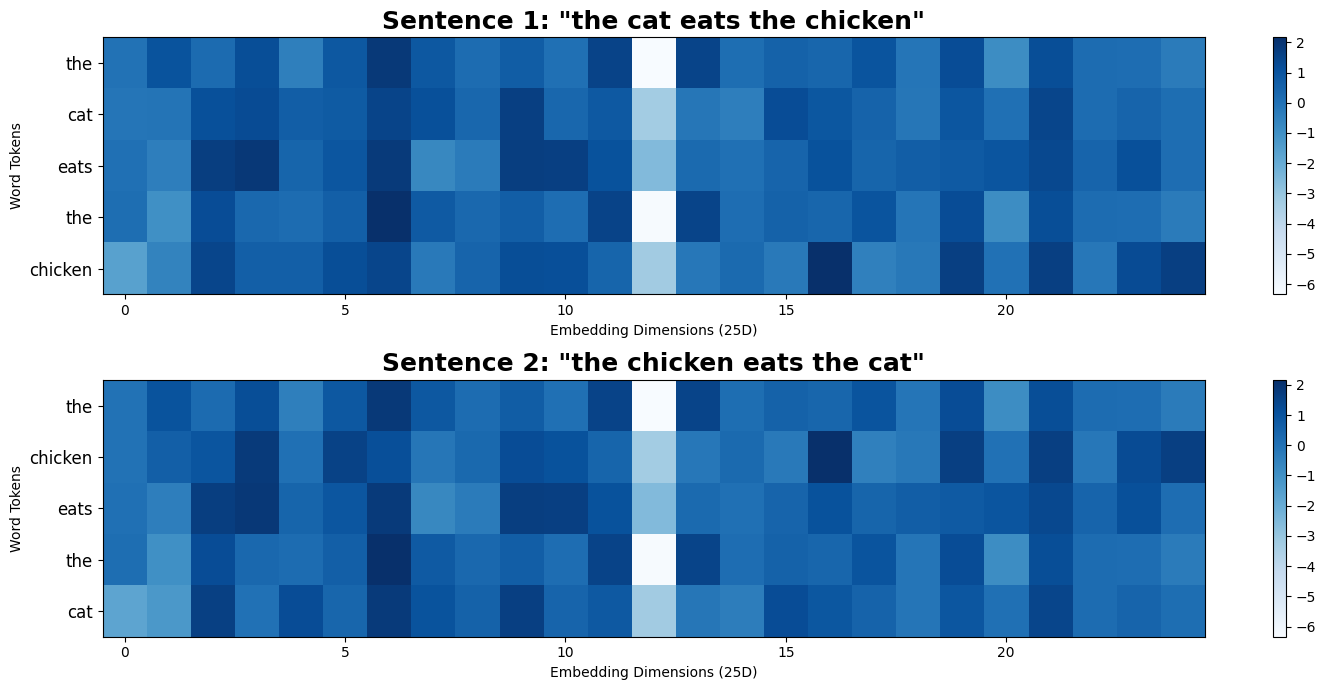

similarity of 'the' (position 0 vs 3): 0.9457
similarity of 'cat' (sentence1 vs sentence2): 0.9012
similarity of 'chicken' (sentence1 vs sentence2): 0.9159


In [ ]:
# Two test sentences with swapped positions
sentences = ["the cat eats the chicken", "the chicken eats the cat"]

# Initialize positional encoding
embed_dim = word2vec.vector_size
pos_encoder = PositionalEncoding(embed_dim, max_len=5)

# Get embeddings with positional encoding
def get_pos_embeddings(sentence):
    tokens = tokenize(sentence)
    embeddings = [get_embedding(token) for token in tokens]
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32).unsqueeze(0)
    pos_encoded = pos_encoder(embeddings_tensor).squeeze(0)
    return tokens, pos_encoded.numpy()

# Process both sentences
results = [get_pos_embeddings(sent) for sent in sentences]
tokens1, pos1 = results[0]
tokens2, pos2 = results[1]

# Visualizations
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

for i, (tokens, pos_embeddings, sentence) in enumerate(zip([tokens1, tokens2], [pos1, pos2], sentences)):
    im = axes[i].imshow(pos_embeddings, cmap='Blues', aspect='auto')
    axes[i].set_title(f'Sentence {i+1}: "{sentence}"', fontsize=18, fontweight='bold')
    axes[i].set_ylabel('Word Tokens')
    axes[i].set_xlabel('Embedding Dimensions (25D)')
    axes[i].set_yticks(range(len(tokens)))
    axes[i].set_yticklabels(tokens, fontsize=12)
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

print(f"similarity of 'the' (position 0 vs 3): {cosine_similarity([pos1[0]], [pos1[3]])[0,0]:.4f}")
print(f"similarity of 'cat' (sentence1 vs sentence2): {cosine_similarity([pos1[1]], [pos2[4]])[0,0]:.4f}")
print(f"similarity of 'chicken' (sentence1 vs sentence2): {cosine_similarity([pos1[4]], [pos2[1]])[0,0]:.4f}")

## **Transformer Architecture**

Now that we have all the ingredients (self-attention, multi-head attention, positional encodings), it’s time to put them together into the **Transformer** — the architecture that reshaped NLP.

At a high level, the Transformer is built from two main components:
- **Encoder** stack  
- **Decoder** stack  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S06_C01/transformer.png" width="350">
  <h5>Figure 4: Encoder and decoder blocks in a transformer</h5>
</div>

**Image Credit:** [Original Paper](https://arxiv.org/abs/1706.03762)

### **Encoder Block**

Each encoder layer has:
1. **Multi-Head Self-Attention**  
   - Lets each word in the input sentence attend to every other word, using multiple attention heads to capture different relational aspects.  

2. **Residual Connections + Layer Normalization**  
   - Residuals help with gradient flow; layer norm stabilizes training.  

3. **Feed-Forward Network (FFN)**  
   - A small fully connected neural network applied identically to each position.  

The encoder stack is simply **N identical layers** of this structure, processing the input sentence and outputting contextual embeddings for every word.

### **Decoder Block**

The decoder layers look similar but include two important differences:  

1. **Masked Multi-Head Self-Attention**  
   - Same as encoder self-attention, but with a mask so a word cannot "see" future tokens.  
   - This allows autoregressive generation, predicting one word at a time.  

2. **Cross-Attention**  
   - Queries come from the decoder’s previous layer.  
   - Keys and Values come from the encoder’s output.  
   - This is how the decoder attends to the input sentence while generating the translation (or output).  

3. **Feed-Forward + Residual + Layer Norm**  
   - Same structure as in the encoder.  

Again, the decoder is **N stacked layers**, enabling deep reasoning over both the input and previously generated outputs.  

In [ ]:
class FeedForward(nn.Module):
    """Position-wise Feed Forward Network"""
    def __init__(self, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ff_dim)
        self.linear2 = nn.Linear(ff_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

### **Transformers in Action**

#### **The Encoder’s Role**
Just like an autoencoder’s encoder compresses an image into a compact code, the **Transformer encoder** takes an input sentence and transforms it into a dense, high-dimensional representation.  

- It doesn’t just see words — it learns **contextualized embeddings**, enriched with positional information.  
- Every word’s meaning gets updated based on its neighbors.  
- The result is a representation space where the **entire sentence’s meaning** is distributed across vectors.  

This makes the encoder an *expert in understanding* — it can capture the full semantics of the input sequence.  

---

#### **The Decoder’s Role**

On the other side, the **Transformer decoder** is like a generative artist.  
It takes two inputs:  

1. The encoder’s contextual embeddings (the *understanding*).  
2. The words generated so far (shifted right, so it doesn’t peek ahead).  

- Through **masked self-attention**, it ensures predictions respect order.  
- Through **cross-attention**, it aligns the generated sequence with the original input.  

This makes the decoder an *expert in creating* — it can **generate new text sequences** (translations, summaries, answers) that are faithful to the input while sounding natural.  

---

#### **Why This is Groundbreaking**
By separating the jobs of *understanding* (encoder) and *generation* (decoder), Transformers gained a unique flexibility:  

- **Translation**: Encode English, decode German/French.  
- **Summarization**: Encode a long article, decode its shorter version.  
- **Question Answering**: Encode context, decode the answer.  
- **Even beyond text**: Encode images, audio, or code — decode captions, transcriptions, or solutions.  

This dual mechanism is why Transformers became the **foundation for modern AI**.  

### **Comparisons With RNNs**

We’ve already seen the promises Transformers made to solve the limitations of RNNs all at once.  
Now let’s see *how* they actually did it:

### **1. Stable Training**
- Thanks to **residual connections** inside every encoder and decoder block, gradients can flow directly across layers.  
- This prevents the **vanishing gradient** problem that crippled deep RNNs, making Transformers scalable to hundreds of layers.  

### **2. No Distance Dependency**
- In RNNs, relationships between words weakened as the distance grew.  
- In Transformers, every word attends to **all other words simultaneously** via attention.  
- This ensures even distant words (e.g., *“not”* and *“good”* separated by 10 tokens) have strong direct links.  

### **3. Full Parallelization**
- RNNs processed words **step by step** → no parallelism.  
- Transformers process **all words in a sequence at once**.  
- This parallelism makes them ideal for GPUs/TPUs.  
- In fact, the original paper reports training their large translation model on **8 P100 GPUs for only 3.5 days** — something utterly impossible for RNNs.  

### **4. Computational Complexity**
Let’s compare the core cost of one forward pass:  

- **RNNs**:  
  Complexity = **O(n·d²)**  
  - For each of `n` tokens, an RNN applies a full matrix multiplication of size `d × d`.  
  - Example: with `n=10`, `d=512` → **2,621,440 operations**.  

- **Self-Attention (Transformers)**:  
  Complexity = **O(n²·d)**  
  - It performs dot products between every pair of tokens, each of dimension `d`.  
  - Example: with `n=10`, `d=512` → **51,200 operations**.  

Since in practice `d` (embedding size, e.g., 512 or 1024) is much larger than `n` (sentence length, often <100), self-attention is **far cheaper** and scales better than RNNs.  

Transformers don’t just avoid the pitfalls of RNNs — they train faster, scale deeper, handle long dependencies, and are more efficient in practice.  
That’s why they became the *default backbone* of modern NLP (and beyond).  

---

### **Proof of Power**
In the original paper *Attention Is All You Need* (2017), Transformers achieved **state-of-the-art results** on machine translation:  

- **English → German**  
- **English → French**  

Both benchmarks were surpassed, setting a *new standard in NLP*.  
This marked the beginning of Transformers as the **go-to architecture** for nearly every sequence-to-sequence task.

In [ ]:
class EncoderBlock(nn.Module):
    """
    Single Transformer Encoder Block
    Architecture: Input -> Multi-Head Attention -> Add & Norm -> Feed Forward -> Add & Norm -> Output
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        """
        Args:
            embed_dim: Dimension of token embeddings (d_model in paper)
            num_heads: Number of parallel attention heads
            ff_dim: Hidden dimension of feed-forward network (typically 4 * embed_dim)
            dropout: Dropout probability for regularization
        """
        super().__init__()
        self.attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.feed_forward = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)  # Layer norm after attention
        self.norm2 = nn.LayerNorm(embed_dim)  # Layer norm after feed-forward
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Forward pass implementing: MultiHeadAttn -> Add&Norm -> FFN -> Add&Norm

        Args:
            x: Input embeddings (batch_size, seq_len, embed_dim)
            mask: Optional attention mask (batch_size, seq_len)

        Returns:
            x: Transformed embeddings (batch_size, seq_len, embed_dim)
            attn_weights: Attention weights for visualization (batch_size, heads, seq_len, seq_len)
        """
        # Multi-head self-attention with residual connection and layer norm
        attn_output, attn_weights = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed-forward with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x, attn_weights

class DecoderBlock(nn.Module):
    """
    Single Transformer Decoder Block
    Architecture: Input -> Masked Self-Attention -> Add&Norm -> Cross-Attention -> Add&Norm -> FFN -> Add&Norm
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        """
        Args:
            similar to the encoder block
        """
        super().__init__()
        # Masked self-attention (decoder tokens attend to previous decoder tokens only)
        self.self_attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)

        # Cross-attention (decoder attends to encoder outputs)
        self.cross_attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout2 = nn.Dropout(dropout)

        # Position-wise feed-forward network
        self.feed_forward = FeedForward(embed_dim, ff_dim, dropout)
        self.norm3 = nn.LayerNorm(embed_dim)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        """
        Forward pass implementing the three sub-layers of decoder block

        Args:
            x: Target embeddings (batch_size, tgt_len, embed_dim)
            enc_out: Encoder outputs (batch_size, src_len, embed_dim)
            src_mask: Source sequence mask (batch_size, src_len)
            tgt_mask: Target sequence mask - typically causal/triangular (batch_size, tgt_len)

        Returns:
            x: Transformed target embeddings (batch_size, tgt_len, embed_dim)
            attention_weights: Tuple of (self_attention_weights, cross_attention_weights)
        """
        # Masked self-attention: target tokens attend to previous target tokens only
        self_attn_output, self_attn_weights = self.self_attention(x, tgt_mask)
        x = self.norm1(x + self.dropout1(self_attn_output))

        # Cross-attention: target tokens (queries) attend to source tokens (keys/values)
        cross_attn_output, cross_attn_weights = self.cross_attention(x, src_mask, enc_out)
        x = self.norm2(x + self.dropout2(cross_attn_output))

        # Position-wise feed-forward network
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_output))

        return x, (self_attn_weights, cross_attn_weights)

class Transformer(nn.Module):
    """
    Complete Transformer Architecture
    Flexible implementation supporting:
    - Encoder-only models (like BERT): Set num_decoders=0
    - Decoder-only models (like GPT): Set num_encoders=0
    - Encoder-Decoder models (like original paper): Both > 0
    """
    def __init__(self, embed_dim, num_heads, num_encoders, num_decoders,
                 ff_dim, dropout=0.1, max_len=512):
        """
        Args:
            embed_dim: Model dimension (d_model in paper) - typically 512
            num_heads: Number of attention heads - typically 8
            num_encoders: Number of encoder blocks to stack (N in paper) - typically 6
            num_decoders: Number of decoder blocks to stack (N in paper) - typically 6
            ff_dim: Feed-forward hidden dimension - typically 4 * embed_dim = 2048
            dropout: Dropout probability for regularization
            max_len: Maximum sequence length for positional encoding
        """
        super().__init__()
        self.embed_dim = embed_dim
        self.pos_encoding = PositionalEncoding(embed_dim, max_len)

        # Encoder stack: N identical layers
        self.encoders = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_encoders)
        ])

        # Decoder stack: N identical layers (empty if encoder-only model)
        self.decoders = nn.ModuleList([
            DecoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_decoders)
        ])

    def forward(self, src, tgt=None, src_mask=None, tgt_mask=None):
        """
        Forward pass through the complete Transformer

        Args:
            src: Source embeddings (batch_size, src_len, embed_dim)
            tgt: Target embeddings (batch_size, tgt_len, embed_dim) - None for encoder-only
            src_mask: Source attention mask (batch_size, src_len)
            tgt_mask: Target attention mask (batch_size, tgt_len) - typically causal

        Returns:
            For encoder-only: (encoded_output, encoder_attention_weights)
            For encoder-decoder: (decoded_output, (encoder_attention_weights, decoder_attention_weights))
        """
        # Add positional encoding to source embeddings
        src = self.pos_encoding(src)
        all_enc_attn_weights = []

        # Pass through encoder stack
        for enc in self.encoders:
            src, attn_w = enc(src, src_mask)
            all_enc_attn_weights.append(attn_w)

        # If no decoders, return encoder output (BERT-style)
        if len(self.decoders) == 0:
            return src, all_enc_attn_weights

        # If decoders exist, process target sequence (original Transformer)
        tgt = self.pos_encoding(tgt)
        all_dec_attn_weights = []

        # Pass through decoder stack
        for dec in self.decoders:
            tgt, attn_w = dec(tgt, src, src_mask, tgt_mask)
            all_dec_attn_weights.append(attn_w)

        return tgt, (all_enc_attn_weights, all_dec_attn_weights)

### **Implementation on "Mouse"**

In this experiment, we trained our custom **TransformerMouse** model to distinguish whether the word *"mouse"* refers to an **animal** or a **computer device**, purely from the **context of the sentence**.

#### **How the Model Works**

1. **Input Sentences**  
   Each sentence is tokenized and converted into embeddings (via Word2Vec).  
   For example:  
   - *"the small mouse with long tail nibbled cheese in the barn"* → *animal* context.  
   - *"a wireless mouse with scroll wheel clicked on the desktop screen"* → *device* context.  

2. **Transformer Encoder**  
   - Sentences pass through stacked **encoder blocks**.  
   - Each block applies:
     - **Multi-Head Attention** → lets every word “see” and attend to every other word.  
     - **Feed-Forward + Residuals + LayerNorm** → stabilizes learning and prevents vanishing gradients.  
   - Positional encodings ensure word order is preserved.

3. **Mouse Token Extraction**  
   We directly extract the contextual embedding of the **"mouse" token** in each sentence.  
   This embedding now carries information about the surrounding words (whether it’s “tail” or “scroll wheel”).

4. **Classification Head**  
   - The embedding goes through a small neural classifier.  
   - Output: **binary prediction** → `0 = animal`, `1 = device`.

### **Training Dynamics**

The model quickly learns to separate the two meanings:  

  - The **classification accuracy reaches 100%** by epoch 7–10.  
  - The **similarity between the two “mouse” embeddings flips negative**, meaning the model has **pushed them apart** in vector space → the animal-mouse and device-mouse meanings are now *distinct clusters*.

### **Attention Visualization**

We then inspected the **attention heads** of the last encoder layer.  

- For the *animal sentence*:  
  The word *“mouse”* strongly attends to words like *“nibbled”* and *“cheese”*.  

- For the *device sentence*:  
  The word *“mouse”* attends more to *“clicked”*, *“desktop”*, and *“wireless”*.  

This shows that **different heads specialize in different relationships**; for instance, the first head seems to be specialized in connecting subjects to their verbs.

### **Final Classification Task**

Finally, we evaluated the model on a set of unseen sentences:  
- Out of 12 test cases, it correctly classified **10 of them**.  
- More importantly, we extracted the **top-attended words** for each decision.  
  - In animal contexts, attention focused on biological cues (*eats, cheese, pet*).  
  - In device contexts, attention focused on technical cues (*computer, screen, wireless*).  

In [ ]:
# --- Create a comprehensive dataset with clear contextual differences ---

# Animal contexts
animal_templates = [
    "the {adj} mouse {action} in the {location}",
    "a mouse with {feature} {action} near the {animal_companion}",
    "the mouse {action} and {action2} in the {habitat}",
    "farmers found the mouse {action} in the {location}",
    "the {animal_companion} chased the mouse that {action}",
    "a {adj} mouse {action} with its {body_part}",
    "the mouse and the {animal_companion} {action} together",
    "wild mouse {action} when they {action2}"
]

# Device contexts
device_templates = [
    "the {adj} mouse {action} on the {surface}",
    "a mouse with {tech_feature} {action} near the {device}",
    "the mouse {action} when the {software} {software_action}",
    "users need the mouse to {action} the {interface_element}",
    "the {device} and mouse {action} via {connection}",
    "a {adj} mouse {action} with its {tech_component}",
    "the mouse and {device} {action} simultaneously",
    "wireless mouse {action} when they {tech_action}"
]

# Rich vocabulary for each context
animal_vocab = {
    'adj': ['small', 'tiny', 'hungry', 'scared', 'wild', 'brown', 'grey', 'quick'],
    'action': ['scurried', 'squeaked', 'nibbled', 'hid', 'ran', 'climbed', 'jumped', 'searched'],
    'action2': ['ate cheese', 'found crumbs', 'built nests', 'dug holes', 'gathered food'],
    'location': ['barn', 'attic', 'basement', 'kitchen', 'garden', 'field', 'warehouse'],
    'animal_companion': ['cat', 'hamster', 'rat', 'rabbit', 'dog', 'owl', 'snake'],
    'habitat': ['forest', 'meadow', 'farm', 'countryside', 'woods', 'grassland'],
    'feature': ['long tail', 'soft fur', 'small ears', 'tiny paws', 'whiskers'],
    'body_part': ['tail', 'paws', 'whiskers', 'teeth', 'ears', 'nose']
}

device_vocab = {
    'adj': ['wireless', 'optical', 'gaming', 'ergonomic', 'bluetooth', 'laser', 'mechanical'],
    'action': ['clicked', 'scrolled', 'connected', 'responded', 'tracked', 'moved', 'dragged'],
    'tech_action': ['lose signal', 'need batteries', 'update firmware', 'calibrate sensors'],
    'surface': ['desk', 'mousepad', 'table', 'workstation', 'surface', 'mat'],
    'device': ['keyboard', 'monitor', 'computer', 'laptop', 'pc', 'screen', 'webcam'],
    'tech_feature': ['scroll wheel', 'dpi settings', 'rgb lighting', 'programmable buttons'],
    'software': ['driver', 'software', 'system', 'application', 'program', 'interface'],
    'software_action': ['updated', 'crashed', 'loaded', 'responded', 'initialized'],
    'interface_element': ['icon', 'button', 'menu', 'window', 'cursor', 'link'],
    'connection': ['usb', 'bluetooth', 'wireless', 'cable', 'dongle', 'receiver'],
    'tech_component': ['sensor', 'battery', 'receiver', 'buttons', 'wheel', 'cable']
}

def generate_sentence(templates, vocab, label):
    template = np.random.choice(templates)
    # Fill template with random vocabulary
    sentence = template.format(**{key: np.random.choice(values)
                                for key, values in vocab.items()})
    return sentence, label

# Generate balanced dataset
dataset = []
n_samples_per_class = 800  # Total of 1600 sentences
set_seed()

for _ in range(n_samples_per_class):
    # Animal context
    sentence, label = generate_sentence(animal_templates, animal_vocab, 0)
    tokens = tokenize(sentence)
    if 'mouse' in tokens:
        mouse_pos = tokens.index('mouse')
        dataset.append((sentence, mouse_pos, label))

for _ in range(n_samples_per_class):
    # Device context
    sentence, label = generate_sentence(device_templates, device_vocab, 1)
    tokens = tokenize(sentence)
    if 'mouse' in tokens:
        mouse_pos = tokens.index('mouse')
        dataset.append((sentence, mouse_pos, label))

np.random.shuffle(dataset)

print(f"Created dataset with {len(dataset)} examples like:")
for sent, pos, lbl in dataset[:5]:
    print(f'{sent:>48} | mouse at position {pos} is {"animal" if lbl==0 else "device"}')

Created dataset with 1600 examples like:
      the mouse scrolled when the program loaded | mouse at position 1 is device
the mouse tracked when the application responded | mouse at position 1 is device
               the pc and mouse scrolled via usb | mouse at position 3 is device
             the snake chased the mouse that hid | mouse at position 4 is animal
           the mouse and the rabbit ran together | mouse at position 1 is animal


In [ ]:
class TransformerMouse(nn.Module):
    def __init__(self, embed_dim, num_heads, num_layers, ff_dim,
                 dropout=0.1, max_len=512):
        super().__init__()
        # We use only the encoder part (decoder = 0)
        self.transformer = Transformer(
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_encoders=num_layers,
            num_decoders=0,        # no decoder for classification
            ff_dim=ff_dim,
            dropout=dropout,
            max_len=max_len
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, 2)  # Binary classification: animal vs device
        )

    def forward(self, x, mask=None, target_positions=None):
        # Encoder-only forward
        x, all_attention_weights = self.transformer(x, src_mask=mask)

        # Extract contextual embeddings for target positions (mouse tokens)
        if target_positions is not None:
            batch_size = x.size(0)
            target_embeddings = x[torch.arange(batch_size), target_positions]
            logits = self.classifier(target_embeddings)
            return logits, target_embeddings, all_attention_weights

        return x, all_attention_weights

def train_model(dataset):
    """Train the Transformer model"""
    set_seed()

    # Split dataset
    train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

    # Prepare embedded datasets
    train_embedded = [(embed_sentence(sent), pos, label) for sent, pos, label in train_data]
    test_embedded = [(embed_sentence(sent), pos, label) for sent, pos, label in test_data]

    # Initialize model
    embed_dim = word2vec.vector_size
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = TransformerMouse(
        embed_dim=embed_dim,
        num_heads=5,
        num_layers=2,
        ff_dim=embed_dim * 2,
        dropout=0.1
    ).to(device)

    # Training setup
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)

    # Training tracking
    train_losses = []
    test_accuracies = []
    similarity_scores = []

    # Sample sentences for similarity tracking
    animal_sentence = "a hungry mouse with long tail nibbled cheese in the barn"
    device_sentence = "a wireless mouse with scroll wheel clicked on the screen"

    batch_size = 64
    print(f"Training Phase Launched...\n{'=' * 60}")

    for epoch in range(10):
        model.train()
        epoch_losses = []

        # Shuffle training data
        np.random.shuffle(train_embedded)

        # Training batches
        for i in range(0, len(train_embedded), batch_size):
            batch = train_embedded[i:i+batch_size]
            padded, masks, positions, labels = pad_collate(batch)

            padded = padded.to(device)
            masks = masks.to(device)
            positions = positions.to(device)
            labels = labels.to(device)

            # Forward pass
            logits, _, _ = model(padded, masks, positions)
            loss = criterion(logits, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        scheduler.step()

        # Evaluation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for i in range(0, len(test_embedded), batch_size):
                batch = test_embedded[i:i+batch_size]
                padded, masks, positions, labels = pad_collate(batch)

                padded = padded.to(device)
                masks = masks.to(device)
                positions = positions.to(device)
                labels = labels.to(device)

                logits, _, _ = model(padded, masks, positions)
                predictions = logits.argmax(dim=-1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        accuracy = correct / total
        avg_loss = np.mean(epoch_losses)

        # Compute contextual similarity
        animal_vec = get_contextual_vector(model, animal_sentence, device)
        device_vec = get_contextual_vector(model, device_sentence, device)
        similarity = cosine_similarity([animal_vec], [device_vec])[0, 0]

        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        similarity_scores.append(similarity)

        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Test Acc: {accuracy:.4f} | Mouse Similarity: {similarity:.4f}")

    return model, train_losses, test_accuracies, similarity_scores

def get_contextual_vector(model, sentence, device):
    """Extract contextual vector for 'mouse' token"""
    model.eval()
    with torch.no_grad():
        embedded = embed_sentence(sentence).unsqueeze(0).to(device)
        mask = torch.ones(1, embedded.size(1), dtype=torch.bool).to(device)
        mouse_pos = torch.tensor([tokenize(sentence).index('mouse')]).to(device)

        _, contextual_vector, _ = model(embedded, mask, mouse_pos)
        return contextual_vector.cpu().numpy().squeeze()

# Train model
model, train_losses, test_accuracies, similarity_scores = train_model(dataset)
device = next(model.parameters()).device

Training Phase Launched...
Epoch  1 | Loss: 0.6865 | Test Acc: 0.7188 | Mouse Similarity: 0.8774
Epoch  2 | Loss: 0.6579 | Test Acc: 0.8125 | Mouse Similarity: 0.8462
Epoch  3 | Loss: 0.6163 | Test Acc: 0.9250 | Mouse Similarity: 0.7329
Epoch  4 | Loss: 0.5515 | Test Acc: 0.9594 | Mouse Similarity: 0.4630
Epoch  5 | Loss: 0.4643 | Test Acc: 0.9875 | Mouse Similarity: 0.0585
Epoch  6 | Loss: 0.3623 | Test Acc: 1.0000 | Mouse Similarity: -0.2611
Epoch  7 | Loss: 0.2934 | Test Acc: 1.0000 | Mouse Similarity: -0.4413
Epoch  8 | Loss: 0.2288 | Test Acc: 1.0000 | Mouse Similarity: -0.5224
Epoch  9 | Loss: 0.1792 | Test Acc: 1.0000 | Mouse Similarity: -0.5628
Epoch 10 | Loss: 0.1493 | Test Acc: 1.0000 | Mouse Similarity: -0.5843


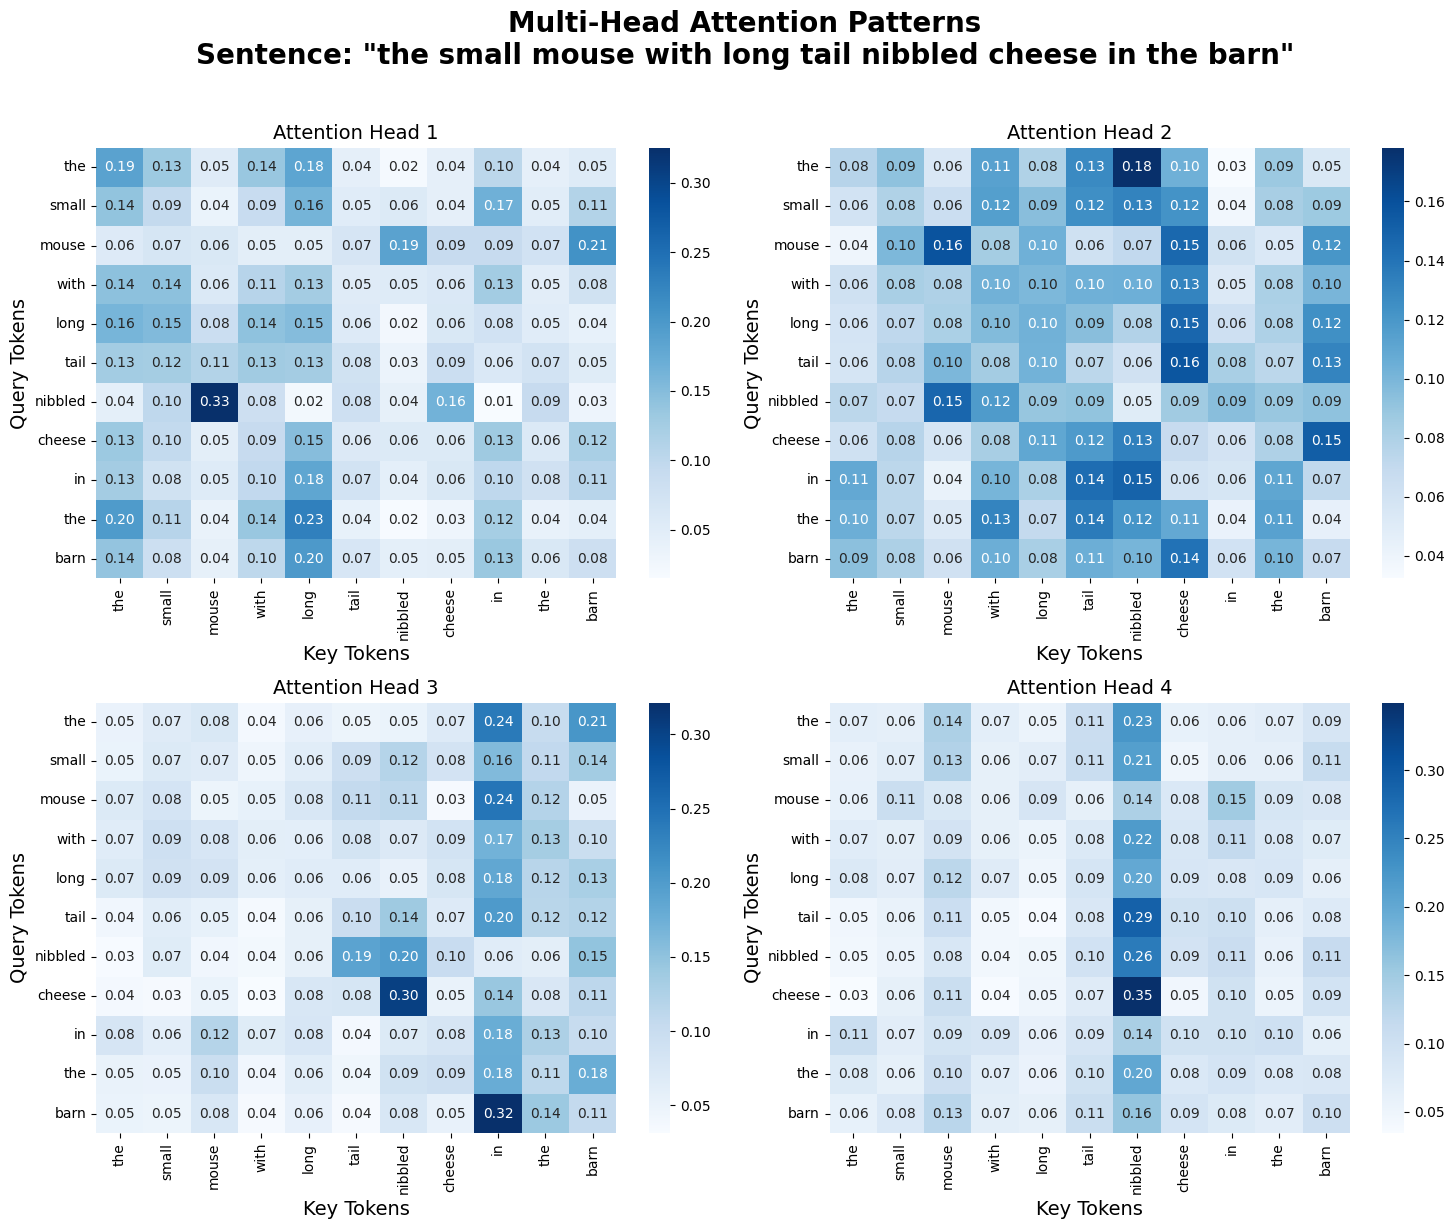

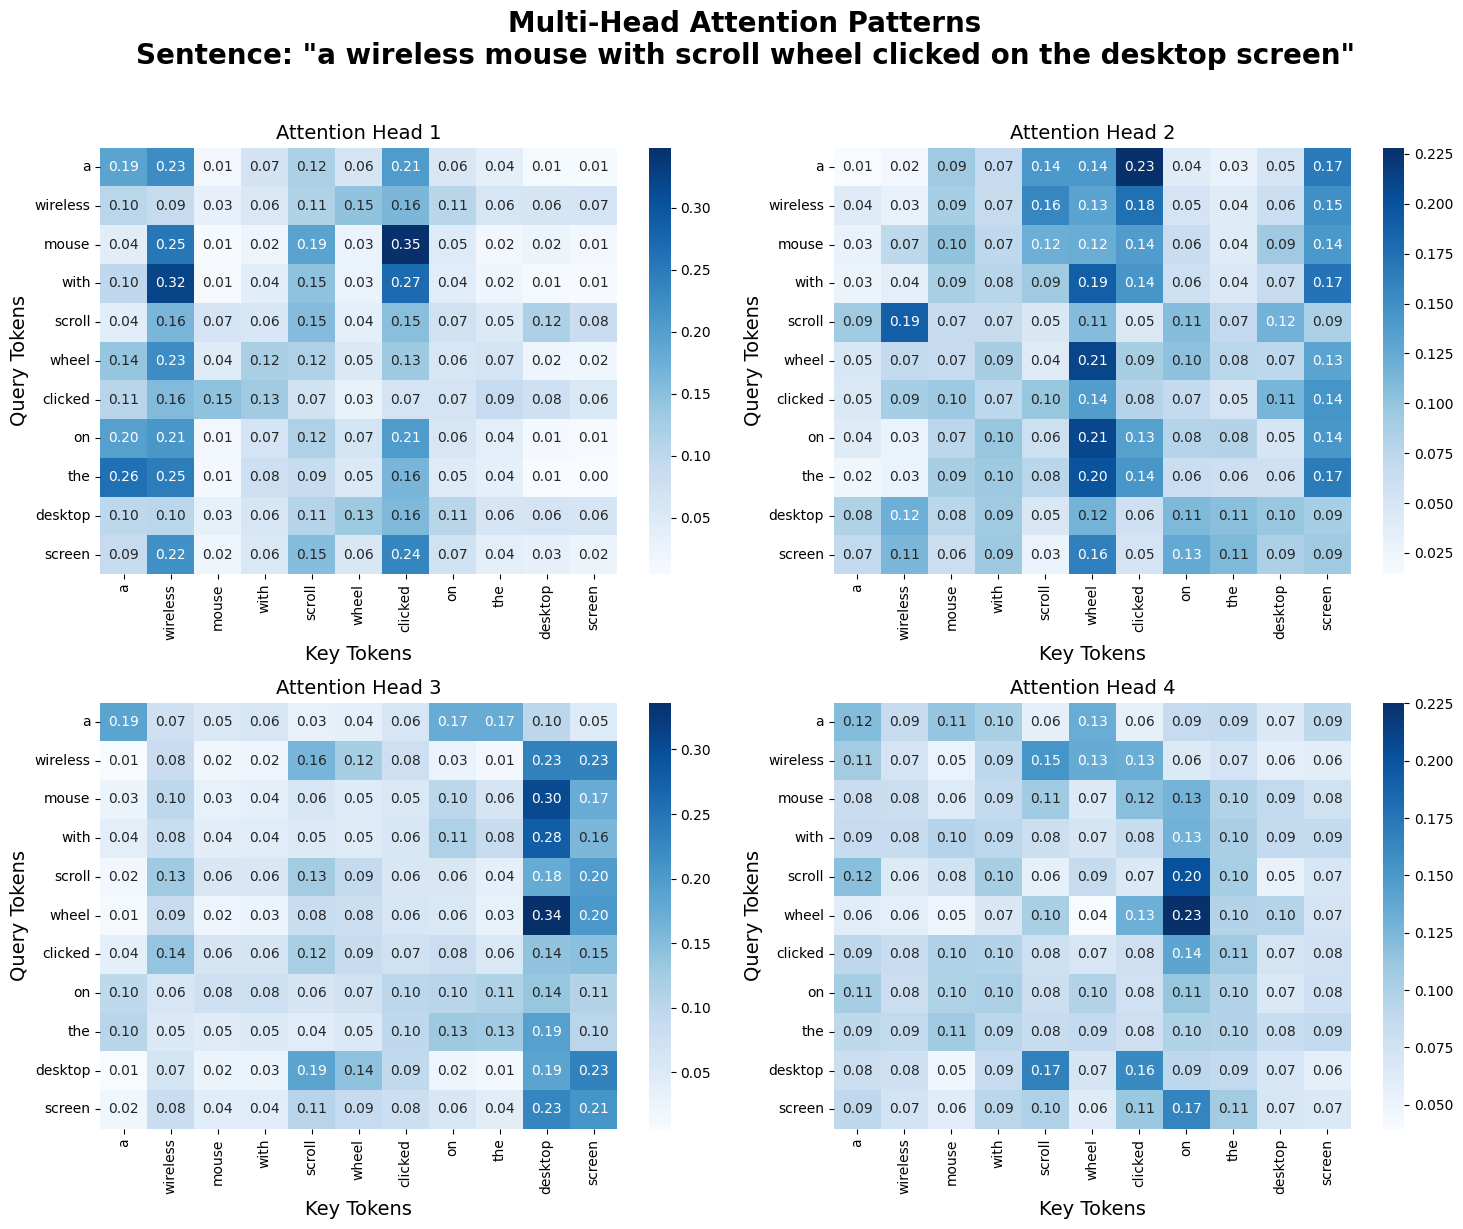

In [ ]:
def visualize_attention_heads(model, sentence, device):
    """Visualize attention patterns for different heads"""
    model.eval()
    with torch.no_grad():
        embedded = embed_sentence(sentence).unsqueeze(0).to(device)
        mask = torch.ones(1, embedded.size(1), dtype=torch.bool).to(device)

        _, attention_weights_all_layers = model(embedded, mask)

        # Focus on the last layer's attention
        attention_weights = attention_weights_all_layers[-1]  # (batch, heads, seq, seq)
        attention_weights = attention_weights.squeeze(0).cpu().numpy()  # (heads, seq, seq)

        tokens = tokenize(sentence)
        num_heads = attention_weights.shape[0]

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()

        for head in range(min(4, num_heads)):
            ax = axes[head]

            # Plot heatmap
            sns.heatmap(
                attention_weights[head],
                xticklabels=tokens,
                yticklabels=tokens,
                cmap='Blues',
                annot=True,
                fmt='.2f',
                cbar=True,
                ax=ax
            )

            ax.set_title(f'Attention Head {head + 1}', fontsize=14)
            ax.set_xlabel('Key Tokens', fontsize=14)
            ax.set_ylabel('Query Tokens', fontsize=14)

        plt.suptitle(f'Multi-Head Attention Patterns\nSentence: "{sentence}"',
                     fontsize=20, y=1.02, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Visualize attention heads
animal_example = "the small mouse with long tail nibbled cheese in the barn"
visualize_attention_heads(model, animal_example, device)

device_example = "a wireless mouse with scroll wheel clicked on the desktop screen"
visualize_attention_heads(model, device_example, device)

In [ ]:
def get_top_attended_words(model, sentence, device, top_k=3):
    """
    Extract top-k words that the model paid most attention to when processing 'mouse'
    Returns the words that most influenced the model's decision
    """
    model.eval()
    with torch.no_grad():
        tokens = tokenize(sentence)
        embedded = embed_sentence(sentence).unsqueeze(0).to(device)
        mask = torch.ones(1, embedded.size(1), dtype=torch.bool).to(device)
        mouse_pos = tokens.index('mouse')

        # Get attention weights from all layers
        _, attention_weights_all_layers = model(embedded, mask)

        # Aggregate attention weights across all layers and heads
        # Focus on attention TO the mouse token (mouse as query)
        total_attention = torch.zeros(len(tokens))

        for layer_attn in attention_weights_all_layers:
            # layer_attn: (batch=1, heads, seq_len, seq_len)
            layer_attn = layer_attn.squeeze(0)  # (heads, seq_len, seq_len)

            # Get attention weights from mouse token to all other tokens
            mouse_attention = layer_attn[:, mouse_pos, :].mean(dim=0)  # Average across heads
            total_attention += mouse_attention.cpu()

        # Normalize by number of layers
        total_attention /= len(attention_weights_all_layers)

        # Get top-k attended words (excluding the mouse token itself)
        attention_scores = [(tokens[i], total_attention[i].item())
                          for i in range(len(tokens)) if i != mouse_pos]
        attention_scores.sort(key=lambda x: x[1], reverse=True)

        return attention_scores[:top_k]

set_seed(41)

# Novel test sentences with minimal overlap to training vocabulary
test_cases = [
    # Animal context
    ("a field mouse mother carried her babies to safety underground", "Animal"),
    ("the house mouse family made cozy nests in the old cabinet", "Animal"),
    ("the pet mouse loves to play and exercise on a wheel everyday", "Animal"),
    ("the big black cat ran after the tiny mouse who eats a cheese", "Animal"),
    ("my mouse likes cheese but is afraid of the cat", "Animal"),
    ("her gray small pet mouse was staring at my touch screen computer", "Animal"),

    # Device context
    ("my computer mouse requires fresh batteries for optimal performance", "Device"),
    ("the ergonomic mouse reduces strain during extended work sessions", "Device"),
    ("this is the third time you break my tiny wireless white mouse", "Device"),
    ("she adjusted mouse sensitivity settings for precise graphic design", "Device"),
    ("the bluetooth mouse automatically pairs with multiple devices seamlessly", "Device"),
    ("gamers prefer high-dpi mouse for competitive online matches", "Device")
]
np.random.shuffle(test_cases)

correct_predictions = 0
total_predictions = len(test_cases)

for i, (sentence, true_context) in enumerate(test_cases, 1):
    # Get model prediction
    model.eval()
    with torch.no_grad():
        embedded = embed_sentence(sentence).unsqueeze(0).to(device)
        mask = torch.ones(1, embedded.size(1), dtype=torch.bool).to(device)
        mouse_pos = torch.tensor([tokenize(sentence).index('mouse')]).to(device)

        logits, _, _ = model(embedded, mask, mouse_pos)
        prediction = logits.argmax(dim=-1).item()
        confidence = F.softmax(logits, dim=-1).max().item()

        predicted_context = "Animal" if prediction == 0 else "Device"
        is_correct = predicted_context == true_context
        if is_correct:
            correct_predictions += 1

        # Get top attended words
        top_words = get_top_attended_words(model, sentence, device, top_k=3)

        # Display results
        status_emoji = "✅" if is_correct else "❌"
        print(f"{status_emoji} Sentence {i:2d}: \"{sentence}\"")
        print(f"   True: {true_context} | Predicted: {predicted_context} ({confidence:.4f})")
        print(f"   Key attention words: {[f'{word}' for word, _ in top_words]}")
        print()

✅ Sentence  1: "my computer mouse requires fresh batteries for optimal performance"
   True: Device | Predicted: Device (0.9111)
   Key attention words: ['optimal', 'batteries', 'computer']

✅ Sentence  2: "my mouse likes cheese but is afraid of the cat"
   True: Animal | Predicted: Animal (0.8946)
   Key attention words: ['cheese', 'afraid', 'cat']

✅ Sentence  3: "this is the third time you break my tiny wireless white mouse"
   True: Device | Predicted: Device (0.6819)
   Key attention words: ['wireless', 'break', 'you']

❌ Sentence  4: "her gray small pet mouse was staring at my touch screen computer"
   True: Animal | Predicted: Device (0.8804)
   Key attention words: ['computer', 'screen', 'staring']

✅ Sentence  5: "she adjusted mouse sensitivity settings for precise graphic design"
   True: Device | Predicted: Device (0.9072)
   Key attention words: ['adjusted', 'settings', 'precise']

✅ Sentence  6: "the ergonomic mouse reduces strain during extended work sessions"
   True: De

## **Closing This Chapter**

In this chapter, we confronted a fundamental limitation of early word representations: a word does not carry meaning in isolation, but **through its context**.  
Static embeddings like Word2Vec, while powerful, fail to capture this reality by assigning a single vector to every word—regardless of how its meaning shifts across sentences.

We explored **RNNs** as an initial attempt to model contextual meaning, only to uncover their inherent weaknesses in scalability, parallelization, and long-range dependency learning.  
This naturally led us to one of the most influential breakthroughs in modern machine learning: **the Transformer**.

By introducing **self-attention**, stacking it into **multi-head attention**, and organizing these mechanisms into **encoder–decoder blocks**, we saw how Transformers learn nuanced, context-dependent meanings—distinguishing effortlessly between *“mouse” the animal* and *“mouse” the device*.  
This chapter marks the moment where sequence modeling truly broke free from recurrence.

Yet, this is not the destination—only the turning point.

### **What’s Next?**
> **Large Language Models**

In the next chapter, we build on the Transformer to explore how scaling, data, and training strategies gave rise to **Large Language Models**, the engines behind many of the most striking advances in NLP today.